In [134]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from datetime import datetime
import os
import geopandas as gpd
from shapely.geometry import Point


In [135]:
path_to_access = "C:/Users/gabriel.battcock/OneDrive - World Food Programme/General - MIMI Project/data_science/country_analysis/lka/accessibility_data/wfp-downscaling-main/local/out_data/"
closeness = pd.read_csv(path_to_access +"closeness_adm2.csv")
entropy = pd.read_csv(path_to_access +"entropy_adm2.csv")
availability =  pd.read_csv(path_to_access +"availability_adm2.csv")
ml_targets = pd.read_csv("../../data/processed/sl_ml_targets_2025-11-13.csv")
hh_info = pd.read_csv("../../data/processed/hh_info.csv")
adm2_average = pd.read_csv("../../data/processed/adm2_average.csv")

In [136]:
shapefile_path = "../../data/processed/shapefile/adm2_shapefile.shp"
adm2_shp = gpd.read_file(shapefile_path)

In [137]:

def df_to_geodf(df, lon_col='longitude', lat_col='latitude', crs="EPSG:4326"):
    """
    Convert a DataFrame with longitude and latitude columns to a GeoDataFrame.
    
    Parameters:
        df (pd.DataFrame): Input DataFrame
        lon_col (str): Column name for longitude
        lat_col (str): Column name for latitude
        crs (str): Coordinate Reference System (default WGS84)
    
    Returns:
        GeoDataFrame
    """
    geometry = [Point(xy) for xy in zip(df[lon_col], df[lat_col])]
    gdf = gpd.GeoDataFrame(df, geometry=geometry, crs=crs)
    return gdf


In [138]:
def create_access_df(df): 
    gdf_points= df_to_geodf(df, "location_longitude","location_latitude")
    matched = gpd.sjoin(gdf_points, adm2_shp, how="left", predicate="within")
    matched = matched[["adm2"] + [col for col in matched.columns if col.startswith('mean_')]]
    matched.columns = ["adm2"] + ["mean" for _ in range(len(matched.columns) - 1)]
    return matched

In [139]:
entropy  = create_access_df(entropy)
availability = create_access_df(availability)
closeness = create_access_df(closeness)

In [140]:
closeness

,adm2,mean
0,11,469.810878
1,12,462.440873
2,13,343.519072
3,21,131.519789
4,22,67.988085
5,23,116.288004
6,31,163.257264
7,32,120.813029
8,33,44.120104
9,41,36.883320


In [141]:
def create_test_df(df, hh_info = hh_info, ml_targets = ml_targets): 
    hh_info = hh_info[['hhid','adm2']]

    # Convert both to string (safe option)
    hh_info['adm2'] = hh_info['adm2'].astype(str)
    df['adm2'] = df['adm2'].astype(str)

    df = hh_info.merge(df, on = 'adm2', how='left')

    df = df.merge(ml_targets, on = 'hhid',how = 'left')


    return df



In [142]:
entropy_test = create_test_df(entropy)
availabilty_test = create_test_df(availability)
closeness_test = create_test_df(closeness)

<positron-console-cell-142>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
<positron-console-cell-142>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
<positron-console-cell-142>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


            hhid adm2      mean iso3      survey  month  vita_rae_mcg  folate_mcg  vitb12_mcg      fe_mg      zn_mg  overall_mar
0       11108811   11  5.853248  LKA  lka_hies19      1    241.031977  166.083003    1.520722  10.766685   8.347197     0.714452
1       11108831   11  5.853248  LKA  lka_hies19      1    199.383626  143.233009    1.760424  10.433142   7.154734     0.671899
2       11108851   11  5.853248  LKA  lka_hies19      1    202.878611  127.903376    1.592757   6.999615   5.421472     0.559565
3       11108861   11  5.853248  LKA  lka_hies19      1    233.094109  156.136737    2.023155   9.046498   6.718921     0.691657
4       11108871   11  5.853248  LKA  lka_hies19      1    319.620585  164.361927    1.872361  13.724426   8.869671     0.831494
...          ...  ...       ...  ...         ...    ...           ...         ...         ...        ...        ...          ...
19906   19208561   92  5.455568  LKA  lka_hies19     12    126.022109  202.143046    0.979918  12

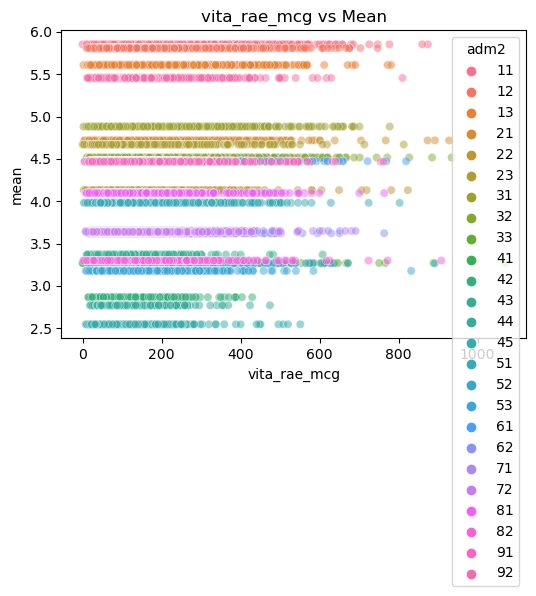

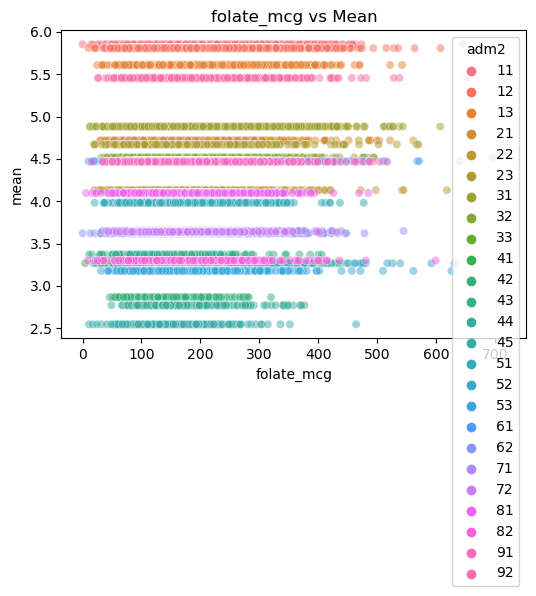

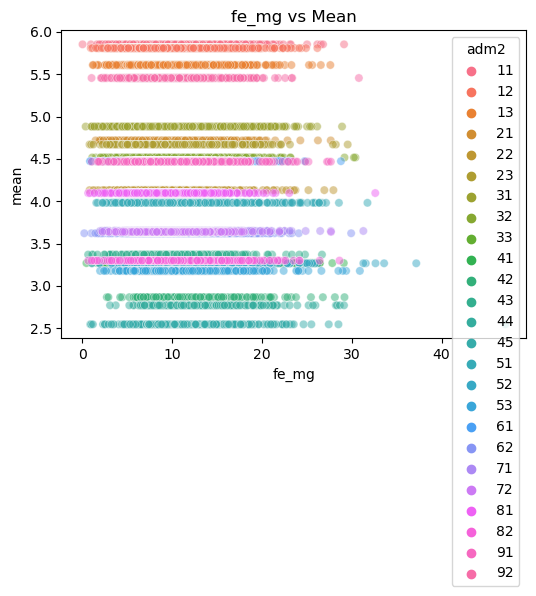

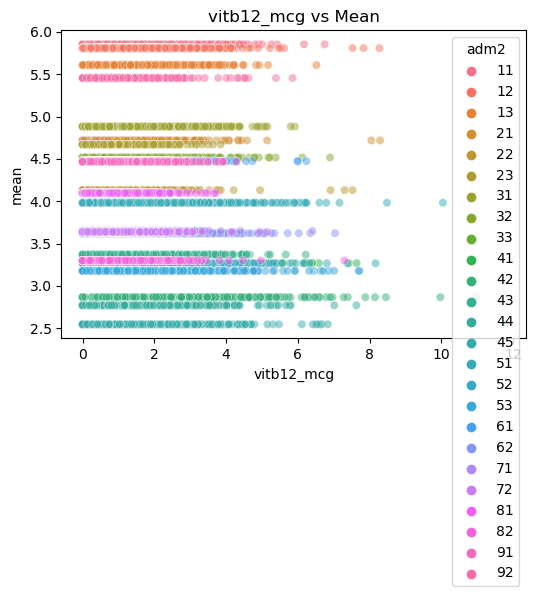

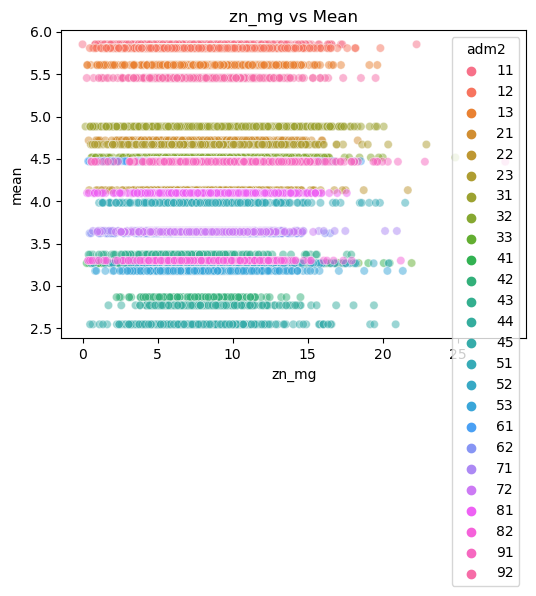

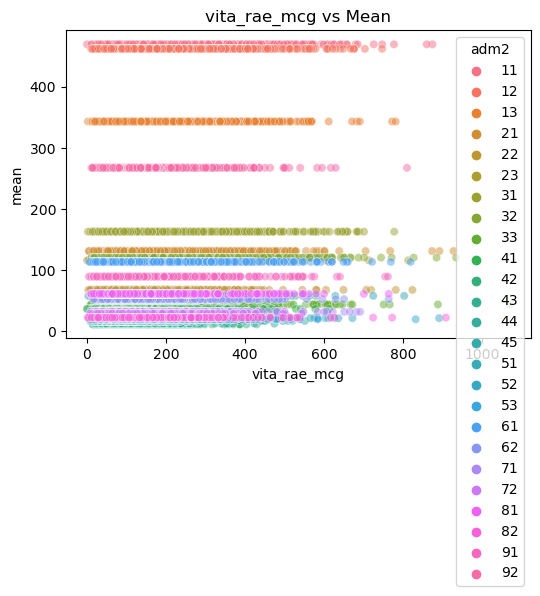

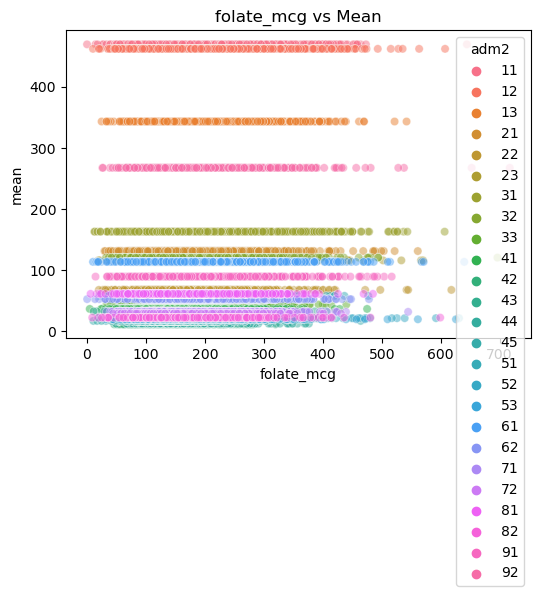

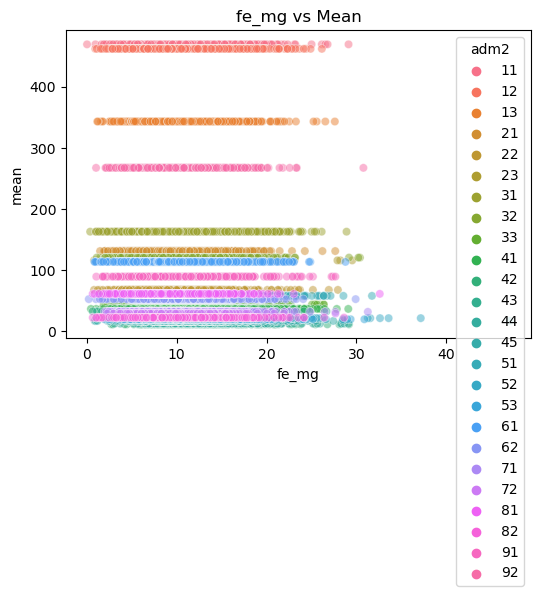

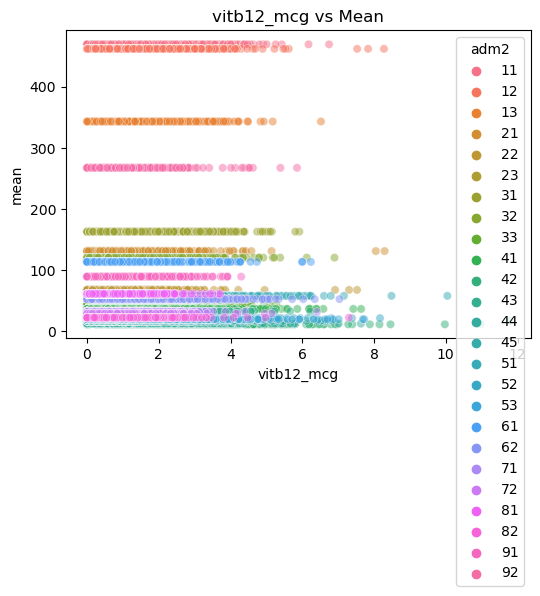

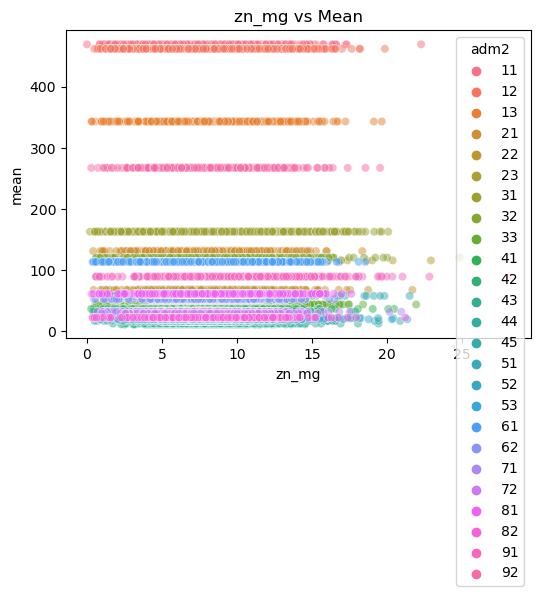

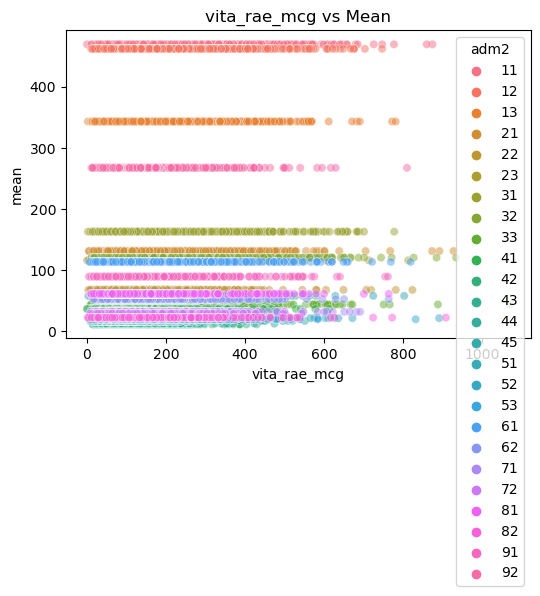

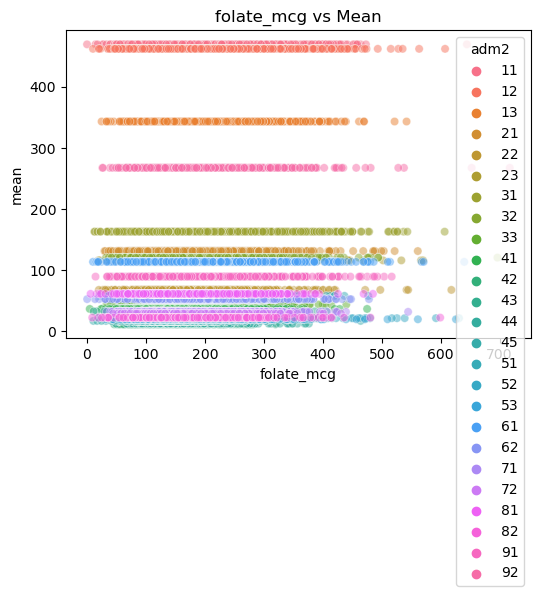

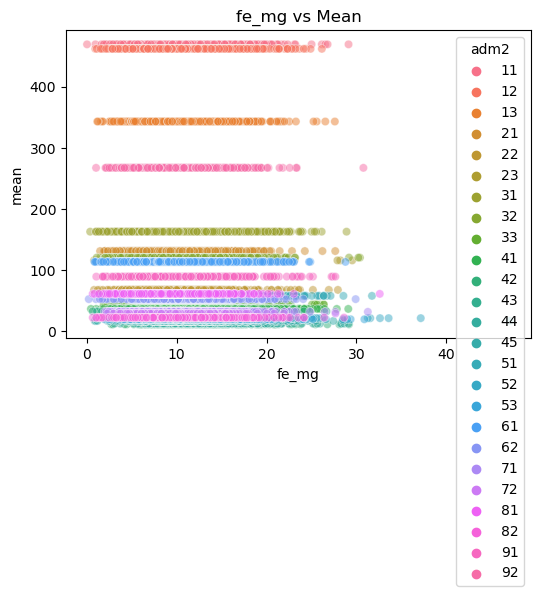

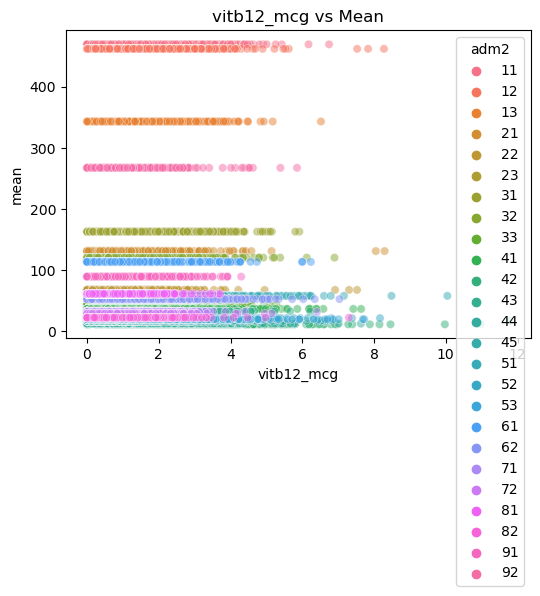

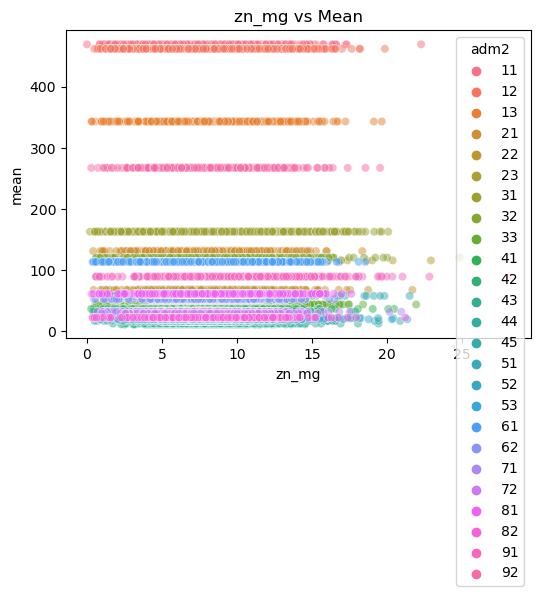

In [144]:
micronutrients = ['vita_rae_mcg', 'folate_mcg', 'fe_mg', 'vitb12_mcg', 'zn_mg']
access = [entropy_test, availabilty_test, closeness_test]

for df in access:
    print(f'{df} \n \n')
    for mn in micronutrients:
        plt.figure(figsize=(6, 4))
        sns.scatterplot(data=df, x=mn, y='mean',
                        hue='adm2', marker='o', alpha=0.5)
        plt.title(f'{mn} vs Mean')
